Imports, Helper Functions & Metrics

In [5]:
import lightgbm
print("LGB loaded")


LGB loaded


In [6]:
print("before TF import")
import tensorflow as tf
print("after TF import")

before TF import
after TF import


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import gc
from pathlib import Path

# --- Configuration ---
DATA_DIR = Path('/Users/AfshiyaRoohi/Downloads/DM/content') 
SAMPLE_SIZE = None # Use 30000 (or None for full dataset)
FORECAST_HORIZON = 28

# --- Helper Functions ---
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to reduce memory usage."""
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and str(col_type)[:3] != 'dat':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min >= 0:
                    if c_max < 255: df[col] = df[col].astype(np.uint8)
                    elif c_max < 65535: df[col] = df[col].astype(np.uint16)
                    elif c_max < 4294967295: df[col] = df[col].astype(np.uint32)
                    else: df[col] = df[col].astype(np.uint64)
                else:
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max: df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max: df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max: df[col] = df[col].astype(np.int32)
                    else: df[col] = df[col].astype(np.int64)
            else:
                df[col] = pd.to_numeric(df[col], downcast='float')
    print(f"Memory usage reduced from {start_mem:.2f} MB to {df.memory_usage().sum() / 1024**2:.2f} MB")
    return df

def create_lag_features(df, group_cols, lag_list):
    for lag in lag_list:
        df[f'lag_{lag}'] = df.groupby(group_cols)['sales'].shift(lag)
    return df

def create_roll_mean_features(df, group_cols, windows):
    for window in windows:
        df[f'rolling_mean_{window}'] = df.groupby(group_cols)['sales'].shift(1).rolling(window).mean().reset_index(0,drop=True)
    return df

def ids_in(df):
    return set(df['id'].unique())

# --- Metrics ---
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred))
    diff = np.abs(y_true - y_pred)
    mask = denominator != 0
    return 100 * np.mean(2.0 * diff[mask] / denominator[mask])

# WRMSSE Helpers
def compute_scales(train_y, seasonality=1, eps=1e-8):
    if seasonality < 1: seasonality = 1
    diffs = train_y[:, seasonality:] - train_y[:, :-seasonality]
    scale = np.sqrt(np.mean(diffs**2, axis=1))
    return np.where(scale <= 0.0, eps, scale)

def compute_weights(train_y, price=None, normalize=True, eps=1e-8):
    mean_qty = train_y.mean(axis=1)
    w = mean_qty if price is None else (mean_qty * np.asarray(price))
    w = np.where(w < 0, 0, w) + eps
    if normalize: w = w / w.sum()
    return w

def wrmsse(y_true, y_pred, scales, weights):
    if y_true.shape != y_pred.shape: raise ValueError("Shapes must match")
    series_rmse  = np.sqrt(np.mean((y_true - y_pred)**2, axis=1))
    series_rmsse = series_rmse / scales
    valid = np.isfinite(series_rmsse) & np.isfinite(weights)
    if not np.any(valid): return np.nan
    w_norm = weights[valid] / weights[valid].sum()
    return float(np.sum(w_norm * series_rmsse[valid]))

def build_matrix(df, ids, value_col):
    df_pivoted = df.pivot(index='id', columns='date', values=value_col).reindex(ids)
    return df_pivoted.to_numpy(na_value=0.0)

print("Setup Complete.")

Setup Complete.


Cell 2: Data Loading & Preprocessing

In [8]:
print("Loading and merging data...")

# --- CHANGE: Use the Evaluation file for more data ---
# This file goes up to d_1941, allowing us to validate on the official d_1914-d_1941 window
sales_df_full = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv')

if SAMPLE_SIZE:
    # We set a random state for reproducibility
    sales_df = sales_df_full.sample(SAMPLE_SIZE, random_state=42)
else:
    sales_df = sales_df_full

del sales_df_full
gc.collect()

calendar_df = pd.read_csv(DATA_DIR / 'calendar.csv')
prices_df = pd.read_csv(DATA_DIR / 'sell_prices.csv')

# Reduce Memory
sales_df = reduce_mem_usage(sales_df)
calendar_df = reduce_mem_usage(calendar_df)
prices_df = reduce_mem_usage(prices_df)

# Melt
df_long = sales_df.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='d', value_name='sales'
)

# Merge
merged_df = df_long.merge(calendar_df, how='left', left_on='d', right_on='d')
merged_df = merged_df.merge(prices_df, how='left', on=['store_id', 'item_id', 'wm_yr_wk'])
merged_df['date'] = pd.to_datetime(merged_df['date'])

# Cleanup
del df_long, sales_df, calendar_df, prices_df
gc.collect()

print(f"Data Loaded. Shape: {merged_df.shape}")

Loading and merging data...
Memory usage reduced from 452.91 MB to 65.72 MB
Memory usage reduced from 0.21 MB to 0.12 MB
Memory usage reduced from 208.77 MB to 143.53 MB
Data Loaded. Shape: (59181090, 22)


Cell 3: Global Metric Calculation
Calculates scales and weights from the FULL history before feature engineering to prevent nan errors.

In [9]:
print("Creating global metrics from full history...")

date_max = merged_df['date'].max()
validation_start_date = date_max - pd.Timedelta(days=FORECAST_HORIZON-1)

# 1. Full Training History (d_1 to d_1913)
train_df_full_history = merged_df[merged_df['date'] < validation_start_date]
# 2. Validation Set (d_1914 to d_1941)
valid_df_full_history = merged_df[merged_df['date'] >= validation_start_date]

GLOBAL_SERIES_IDS = sorted(list(train_df_full_history['id'].unique()))

print(f"Building matrices for {len(GLOBAL_SERIES_IDS)} series...")
train_y_full_matrix = build_matrix(train_df_full_history, GLOBAL_SERIES_IDS, 'sales')
TRUE_MATRIX = build_matrix(valid_df_full_history, GLOBAL_SERIES_IDS, 'sales')

# Calculate Scales & Weights
GLOBAL_SCALES = compute_scales(train_y_full_matrix, seasonality=7)
GLOBAL_WEIGHTS = compute_weights(train_y_full_matrix, price=None, normalize=True)

print("Global metrics created.")
del train_df_full_history, valid_df_full_history, train_y_full_matrix
gc.collect()

Creating global metrics from full history...
Building matrices for 30490 series...
Global metrics created.


0

Cell 4: Feature Engineering (V2)
Adds price, lag, rolling, and categorical features.

In [10]:
print("Engineering Features...")
features_df = merged_df.copy()

# Calendar
features_df['day_of_week'] = features_df['date'].dt.weekday
features_df['week_of_year'] = features_df['date'].dt.isocalendar().week.astype(int)
features_df['month'] = features_df['date'].dt.month
features_df['year'] = features_df['date'].dt.year

# Lags & Rolling
features_df = create_lag_features(features_df, group_cols=['id'], lag_list=[1, 7, 14, 28])
features_df = create_roll_mean_features(features_df, group_cols=['id'], windows=[7, 28])

# Price Features
features_df['price_lag_1'] = features_df.groupby(['id'])['sell_price'].shift(1)
features_df['price_change_1'] = features_df['sell_price'] / features_df['price_lag_1'] - 1.0

# Categorical Handling
event_cols = ['event_name_1', 'event_type_1']
for col in event_cols:
    features_df[col] = features_df[col].fillna('None').astype('category')

cat_feats = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'] + event_cols
for col in cat_feats:
    if col in features_df.columns:
        features_df[col] = features_df[col].astype('category')

# Define Feature Set
features = [
    'day_of_week','week_of_year','month','year',
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_28',
    'sell_price', 'price_change_1'
] + cat_feats

target_col = 'sales'

# --- Split Train/Valid ---
# Important: Split first, then drop NaNs only from training to keep validation size correct
train_df = features_df[features_df['date'] < validation_start_date].copy()
valid_df = features_df[features_df['date'] >= validation_start_date].copy()

# Prepare Training Data (Drop NaNs caused by lags)
X_train = train_df.dropna(subset=features)[features]
y_train = train_df.dropna(subset=features)[target_col]

# Prepare Validation Data (Keep full length)
X_valid = valid_df[features]
y_valid = valid_df[target_col]

print(f"Train Shape: {X_train.shape}, Valid Shape: {X_valid.shape}")
del features_df, train_df
gc.collect()

Engineering Features...
Train Shape: (45672691, 19), Valid Shape: (853720, 19)


0

Cell 5: Model 1 - LightGBM (Tuned)

In [11]:
print("Training LightGBM (Tuned)...")

# Best parameters from your Optuna study
params = {
    'learning_rate': 0.06794580482636105,
    'num_leaves': 62,
    'max_depth': 17,
    'subsample': 0.6812421538694611,
    'colsample_bytree': 0.8670698615463088,
    'n_estimators': 3000,
    'objective': 'tweedie', # Critical for sparse data
    'metric': 'mae',
    'n_jobs': -1,
    'random_state': 42
}

lgb_model = LGBMRegressor(**params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(50, verbose=100)],
    categorical_feature=cat_feats # Explicitly handle categoricals
)

lgb_preds = lgb_model.predict(X_valid)
valid_df['lgb_pred'] = lgb_preds
print("LightGBM Predictions Created.")

Training LightGBM (Tuned)...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.157438 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4258
[LightGBM] [Info] Number of data points in the train set: 45672691, number of used features: 19
[LightGBM] [Info] Start training from score 0.352191
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1661]	valid_0's l1: 1.01421
LightGBM Predictions Created.


Cell 6: Model 2 - Random Forest
Trains a Random Forest for comparison (using faster settings).

In [12]:
print("Training Random Forest (Comparison)...")

# RF cannot handle 'category' type directly, convert to codes
X_train_rf = X_train.copy()
X_valid_rf = X_valid.copy()

for col in X_train_rf.select_dtypes(include=['category']).columns:
    X_train_rf[col] = X_train_rf[col].cat.codes
    X_valid_rf[col] = X_valid_rf[col].cat.codes

rf_model = RandomForestRegressor(
    n_estimators=30,      # Reduced for speed
    max_depth=12,         # Reduced for speed
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_rf, y_train)
rf_preds = rf_model.predict(X_valid_rf)
valid_df['rf_pred'] = rf_preds
print("Random Forest Predictions Created.")
del X_train_rf, X_valid_rf
gc.collect()

Training Random Forest (Comparison)...
Random Forest Predictions Created.


75

Cell 7: Model 3 - Deep Learning (LSTM)
Implements the "Hybrid" DL component.

In [13]:
print("Training LSTM (Deep Learning)...")

# 1. Prepare Data
# LSTMs need numeric input (no categories) and scaling
# We will use the RF encoded features (numeric) for simplicity

# Create separate scalers for features and target
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))

# Convert features to numeric codes for LSTM
X_train_lstm_data = X_train.copy()
X_valid_lstm_data = X_valid.copy()
for col in X_train_lstm_data.select_dtypes(include=['category']).columns:
    X_train_lstm_data[col] = X_train_lstm_data[col].cat.codes
    X_valid_lstm_data[col] = X_valid_lstm_data[col].cat.codes

# Scale features using x_scaler
X_train_scaled = x_scaler.fit_transform(X_train_lstm_data)
X_valid_scaled = x_scaler.transform(X_valid_lstm_data)

# Reshape for LSTM: [Samples, Timesteps, Features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_valid_lstm = X_valid_scaled.reshape((X_valid_scaled.shape[0], 1, X_valid_scaled.shape[1]))

# 2. Build Model
model = Sequential()
model.add(Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(LSTM(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 3. Train
history = model.fit(
    X_train_lstm, y_train_scaled,
    epochs=3, # Keep low for demonstration speed
    batch_size=2048,
    verbose=1
)

# 4. Predict
lstm_preds_scaled = model.predict(X_valid_lstm)
# Inverse transform target using y_scaler
lstm_preds = y_scaler.inverse_transform(lstm_preds_scaled).flatten()
valid_df['lstm_pred'] = lstm_preds
print("LSTM Predictions Created.")

Training LSTM (Deep Learning)...


2025-12-03 13:46:07.663772: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-12-03 13:46:07.666656: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-03 13:46:07.666857: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-12-03 13:46:07.666908: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-03 13:46:07.667145: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/3


2025-12-03 13:46:16.193283: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


22302/22302 ━━━━━━━━━━━━━━━━━━━━ 347s 15ms/step - loss: 1.2985e-05
Epoch 2/3
22302/22302 ━━━━━━━━━━━━━━━━━━━━ 360s 16ms/step - loss: 1.0999e-05
Epoch 3/3
22302/22302 ━━━━━━━━━━━━━━━━━━━━ 359s 16ms/step - loss: 1.0954e-05
26679/26679 ━━━━━━━━━━━━━━━━━━━━ 108s 4ms/step
LSTM Predictions Created.


Cell 8: Final Evaluation & Table
Calculates metrics for all models and displays the final project table.

In [14]:
print("Calculating Final Metrics...")

# 1. Prepare Prediction Matrices
lgb_matrix = build_matrix(valid_df, GLOBAL_SERIES_IDS, 'lgb_pred')
rf_matrix = build_matrix(valid_df, GLOBAL_SERIES_IDS, 'rf_pred')
lstm_matrix = build_matrix(valid_df, GLOBAL_SERIES_IDS, 'lstm_pred')

# --- NEW: Create Ensemble (Hybrid) Predictions ---
# Simple average of your best ML model (LGBM) and DL model (LSTM)
ensemble_matrix = (lgb_matrix + lstm_matrix) / 2

# 2. Evaluation Function
def eval_all_global(y_true, y_pred):
    return {
        "WRMSSE": wrmsse(y_true, y_pred, GLOBAL_SCALES, GLOBAL_WEIGHTS),
        "MAE":    mae(y_true.ravel(),  y_pred.ravel()),
        "sMAPE":  smape(y_true.ravel(), y_pred.ravel())
    }

# 3. Compile Results
results = {
    "LightGBM (Tuned)": eval_all_global(TRUE_MATRIX, lgb_matrix),
    "Random Forest": eval_all_global(TRUE_MATRIX, rf_matrix),
    "LSTM (Deep Learning)": eval_all_global(TRUE_MATRIX, lstm_matrix),
    "Hybrid Ensemble (LGBM+LSTM)": eval_all_global(TRUE_MATRIX, ensemble_matrix) # Added this line
}

# 4. Baselines (Hardcoded from Checkpoint 1)
results["Naive"] = {"WRMSSE": 0.9119, "MAE": 1.1699, "sMAPE": 132.11}
results["Seasonal Naive"] = {"WRMSSE": 0.9284, "MAE": 1.1963, "sMAPE": 133.59}

# 5. Display
final_df = pd.DataFrame(results).T.sort_values("WRMSSE")
print("\n--- FINAL PROJECT RESULTS ---")
display(final_df)
final_df.to_csv('final_project_results.csv')

Calculating Final Metrics...

--- FINAL PROJECT RESULTS ---


,WRMSSE,MAE,sMAPE
LightGBM (Tuned),0.713512,1.014210,139.074669
Hybrid Ensemble (LGBM+LSTM),0.721827,1.027714,139.601387
Random Forest,0.742466,1.072547,139.314098
LSTM (Deep Learning),0.748442,1.061207,141.528833
Naive,0.911900,1.169900,132.110000
Seasonal Naive,0.928400,1.196300,133.590000


--- Performing Hierarchical Reconciliation (Bottom-Up) ---


/var/folders/9y/z1bm7yg53q59p7g8py7826b00000gn/T/ipykernel_48825/547006478.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['date'] + group_cols)[['sales', 'lgb_pred']].sum().reset_index()
/var/folders/9y/z1bm7yg53q59p7g8py7826b00000gn/T/ipykernel_48825/547006478.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['date'] + group_cols)[['sales', 'lgb_pred']].sum().reset_index()


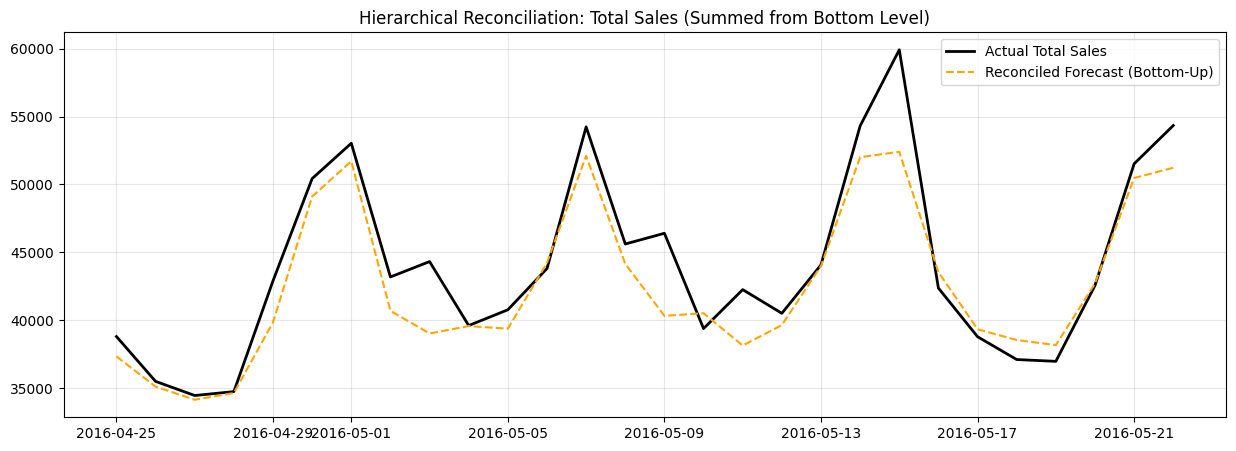


--- Hierarchical Accuracy (MAE) ---
Total Sales MAE: 1856.73


In [15]:
print("--- Performing Hierarchical Reconciliation (Bottom-Up) ---")

# 1. Create a DataFrame with your best predictions
# We use the validation dataframe which already has 'sales' (actual) and 'lgb_pred' (predicted)
hierarchy_df = valid_df.copy()

# 2. Define the Bottom-Up Aggregation
def get_aggregates(df, level_name, group_cols):
    """Sums up Level 12 predictions to creating higher-level forecasts."""
    agg = df.groupby(['date'] + group_cols)[['sales', 'lgb_pred']].sum().reset_index()
    agg['level'] = level_name
    return agg

# 3. Create Aggregates for key levels
# Level 1: Total Unit Sales (The top of the hierarchy)
level_1 = get_aggregates(hierarchy_df, 'Total (Level 1)', [])

# Level 2: Sales per State
level_2 = get_aggregates(hierarchy_df, 'State (Level 2)', ['state_id'])

# Level 3: Sales per Store
level_3 = get_aggregates(hierarchy_df, 'Store (Level 3)', ['store_id'])

# 4. Visualization: Plot Actual vs. Reconciled Forecasts
# This proves your bottom-level models can accurately predict the total company sales!
plt.figure(figsize=(15, 5))
plt.plot(level_1['date'], level_1['sales'], label='Actual Total Sales', color='black', linewidth=2)
plt.plot(level_1['date'], level_1['lgb_pred'], label='Reconciled Forecast (Bottom-Up)', color='orange', linestyle='--')
plt.title("Hierarchical Reconciliation: Total Sales (Summed from Bottom Level)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Hierarchical Accuracy (MAE) ---")
print(f"Total Sales MAE: {mean_absolute_error(level_1['sales'], level_1['lgb_pred']):.2f}")